# Grad-CAM: How to visualize class activation maps to bring Interpretability to Deep Learning

IMPORTANT: If you are a student, click on "File -> Save a copy in Drive" before using it

In this tutorial, you will learn how to visualize class activation maps using an algorithm called Grad-CAM (original article here: https://arxiv.org/pdf/1611.07450.pdf). It will be implemented using Keras, inspired by the code proposed by F.Chollet (https://github.com/keras-team/keras-io/blob/master/examples/vision/grad_cam.py).

Deep Learning models are considered [black box] models as we don't know why a certain output is linked to a certain input.

As explained in the original article, "Grad-CAM uses the gradient of any target concept (say logits for [dog] or even a caption predicted for an input image), flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image for predicting the concept."

Expressed in a simpler way, we can consider that the Grad-CAM method makes it possible to know which part of the image the model looked at to make its decision or, more exactly which part of the image contributed the most to its prediction.

Why would we want to visualize class activation maps in Convolutional Neural Networks? In fact, we want to be sure that the model is taking a decision for the right reason and that it does not contain any inner bias. More concretely and to take an example, we want the model to be able to detect an elephant because it looks like an elephant and not because there is a savanna background around it, as we want to be able to detect an elephant in any context.

The concept is simple and straightforward as we are going to:

1.   find and isolate the final convolutional layer in a pre-trained deep neural network
2.   compute the gradient flowing into that layer and color its value as a heatmap


## Setup

In [3]:
# Usual Imports for Deep Learning
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Display
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm


Here we are going to use the model ResNet50 (doc here: https://keras.io/api/applications/resnet/). You can change it to use any other model.

ResNet50 (Deep Residual Network with 50 layers) is a widely used convolutional neural network pre-trained on ImageNet. Its key innovation is the use of **residual connections** (skip connections) that allow gradients to flow more easily during training, enabling much deeper architectures without the vanishing gradient problem.

We use `model.summary()` to see the names of all layers in the model and find the name of the last convolutional layer.

In [4]:
# Prepare the model. model_builder() is used to load ResNet50 with Keras
# You can check the documentation of those functions on https://www.tensorflow.org
model_builder = keras.applications.ResNet50
img_size = (224, 224)
preprocess_input = keras.applications.resnet.preprocess_input
decode_predictions = keras.applications.resnet.decode_predictions

# Create the model, by using pretrained weights on ImageNet
model = model_builder(weights="imagenet")
print(model.summary())


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


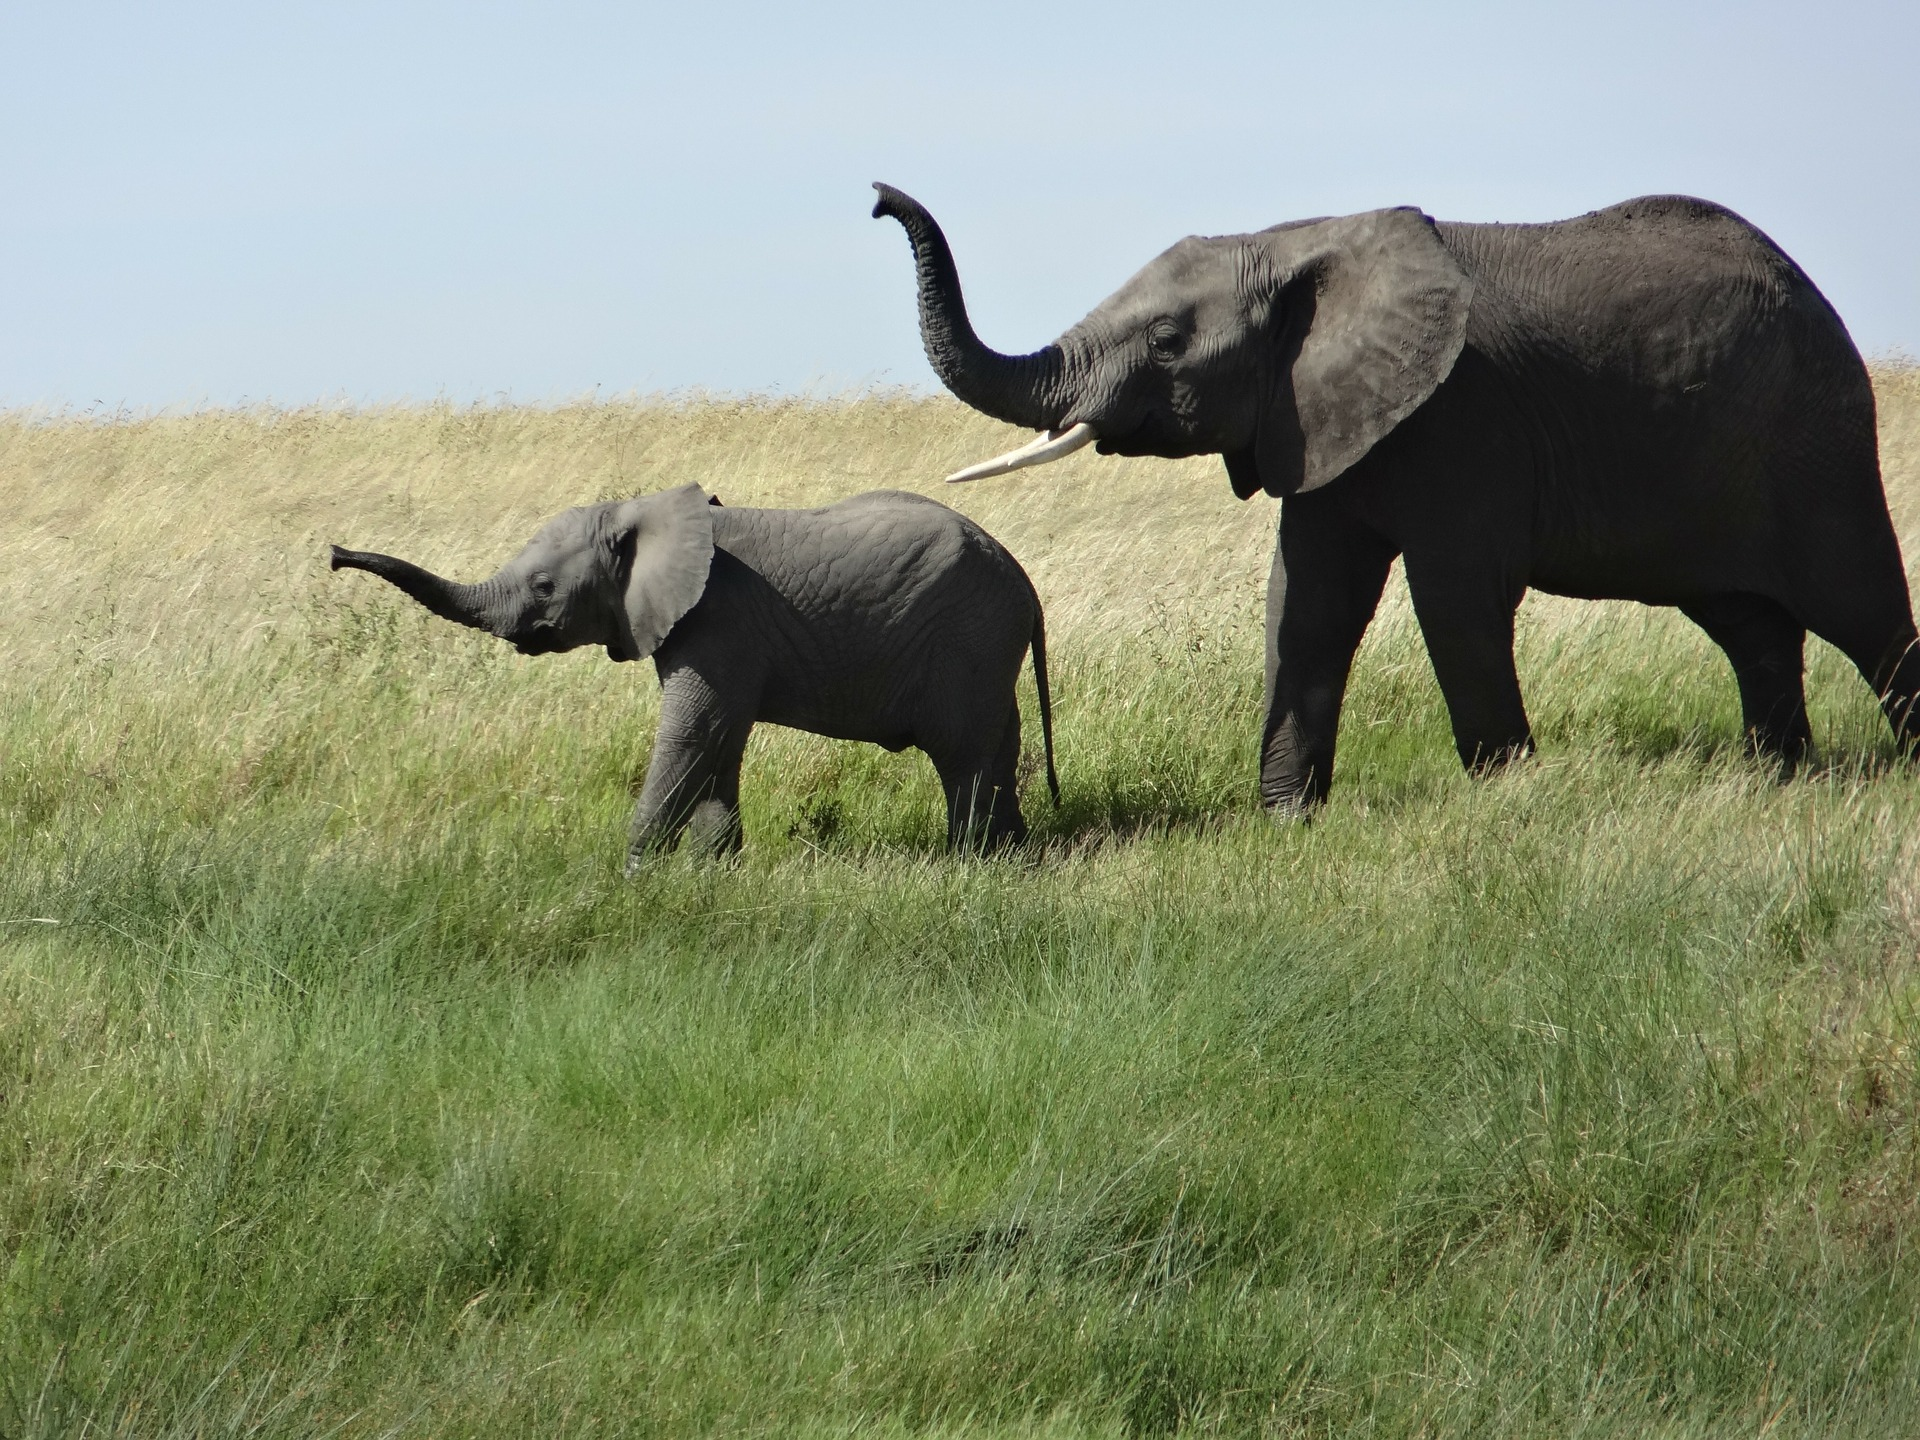

In [7]:
# Isolate the last convolutional layer
# In ResNet50, the last convolutional activation layer is "conv5_block3_out"
# It produces feature maps of shape (7, 7, 2048) before global average pooling
last_conv_layer_name = "conv5_block3_out"
classifier_layer_names = [
    "avg_pool",
    "predictions",
]

# The local path to our target image
# We use an elephant image, a classic example for ImageNet-based models
img_path = "elephant.png" 

# Visualize the image
display(Image(img_path))


## The Grad-CAM algorithm

In [8]:
def get_img_array(img_path, size):
    # `img` is a PIL image of size 224x224
    img = keras.preprocessing.image.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (224, 224, 3)
    array = keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 224, 224, 3). We do this because this dimension is needed for most built-in functions
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, classifier_layer_names, prediction_rank=1):
    # The variable "prediction_rank" is used to apply gradcam on the top class
    # You can modify it to prediction_rank=n for a heatmap on the nth top class

    # First, we create a model that maps the input image to the activations of the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

    # Second, we create a model that maps the activations of the last conv layer to the final class predictions
    classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer_name in classifier_layer_names:
        x = model.get_layer(layer_name)(x)
    classifier_model = keras.Model(classifier_input, x)

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        # GradientTape() is a built-in Tensorflow tool to record operations for automatic differentiation.
        # https://www.tensorflow.org/api_docs/python/tf/GradientTape
        # We compute activations of the last conv layer and make the tape watch it
        last_conv_layer_output = last_conv_layer_model(img_array)
        tape.watch(last_conv_layer_output)
        # Compute class predictions
        # We pass the activations of the last conv in our classifier_model to obtain the predictions of the model
        preds = classifier_model(last_conv_layer_output)
        # This prediction has a shape=(1, 1000) because there is 1000 classes in ImageNet.
        # We find the index of the top prediction and we call it pred_index, because it's the index of the prediction
        pred_index = tf.argsort(preds)[0][-prediction_rank]
        # We only keep the value of the prediction at the position of the pred_index
        top_class_channel = preds[:, pred_index]


    # This is the gradient of the top predicted class with respect to
    # the output feature map of the last conv layer
    grads = tape.gradient(top_class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with respect to the top predicted class
    last_conv_layer_output = last_conv_layer_output.numpy()[0]
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]

    # The channel-wise mean of the resulting feature map
    # is our heatmap of activation for the top class
    heatmap = np.mean(last_conv_layer_output, axis=-1)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap


## Let's use it

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Top 1 Prediction: [('n02504458', 'African_elephant', np.float32(0.6776625))]
Top 3 Predictions: [('n02504458', 'African_elephant', np.float32(0.6776625)), ('n02408429', 'water_buffalo', np.float32(0.14404453)), ('n02397096', 'warthog', np.float32(0.08177308))]


c:\Users\skand\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


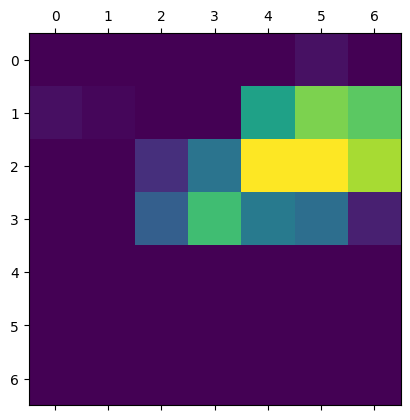

In [9]:
# Prepare image
img_array = preprocess_input(get_img_array(img_path, size=img_size))

# Print what the top predicted class is (African elephant in ImageNet labels)
# According to https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/decode_predictions
# decode_predictions() returns a list of lists of top class prediction tuples (class_name, class_description, score)
# class_name is the internal name of the class, class_description the name in natural language and score is the probability of this prediction.
# top=1 is used to have the top class and [0] to have the first element of the list.
preds = model.predict(img_array)
print("Top 1 Prediction:", decode_predictions(preds, top=1)[0])

# In order to check the 2nd and 3rd predicted class, we also print the predictions with top=3
print("Top 3 Predictions:", decode_predictions(preds, top=3)[0])

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, classifier_layer_names
)

# Display heatmap. This heatmap is normalized for visualisation purpose, as explained in make_gradcam_heatmap()
# Thanks to that, we can know what part of the image was the most important to predict the top class
plt.matshow(heatmap)
plt.show()


## Create a superimposed visualization

Finally, we are going to superimpose this heatmap to the input image in order to easily visualize it

C:\Users\skand\AppData\Local\Temp\ipykernel_3268\3209546919.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


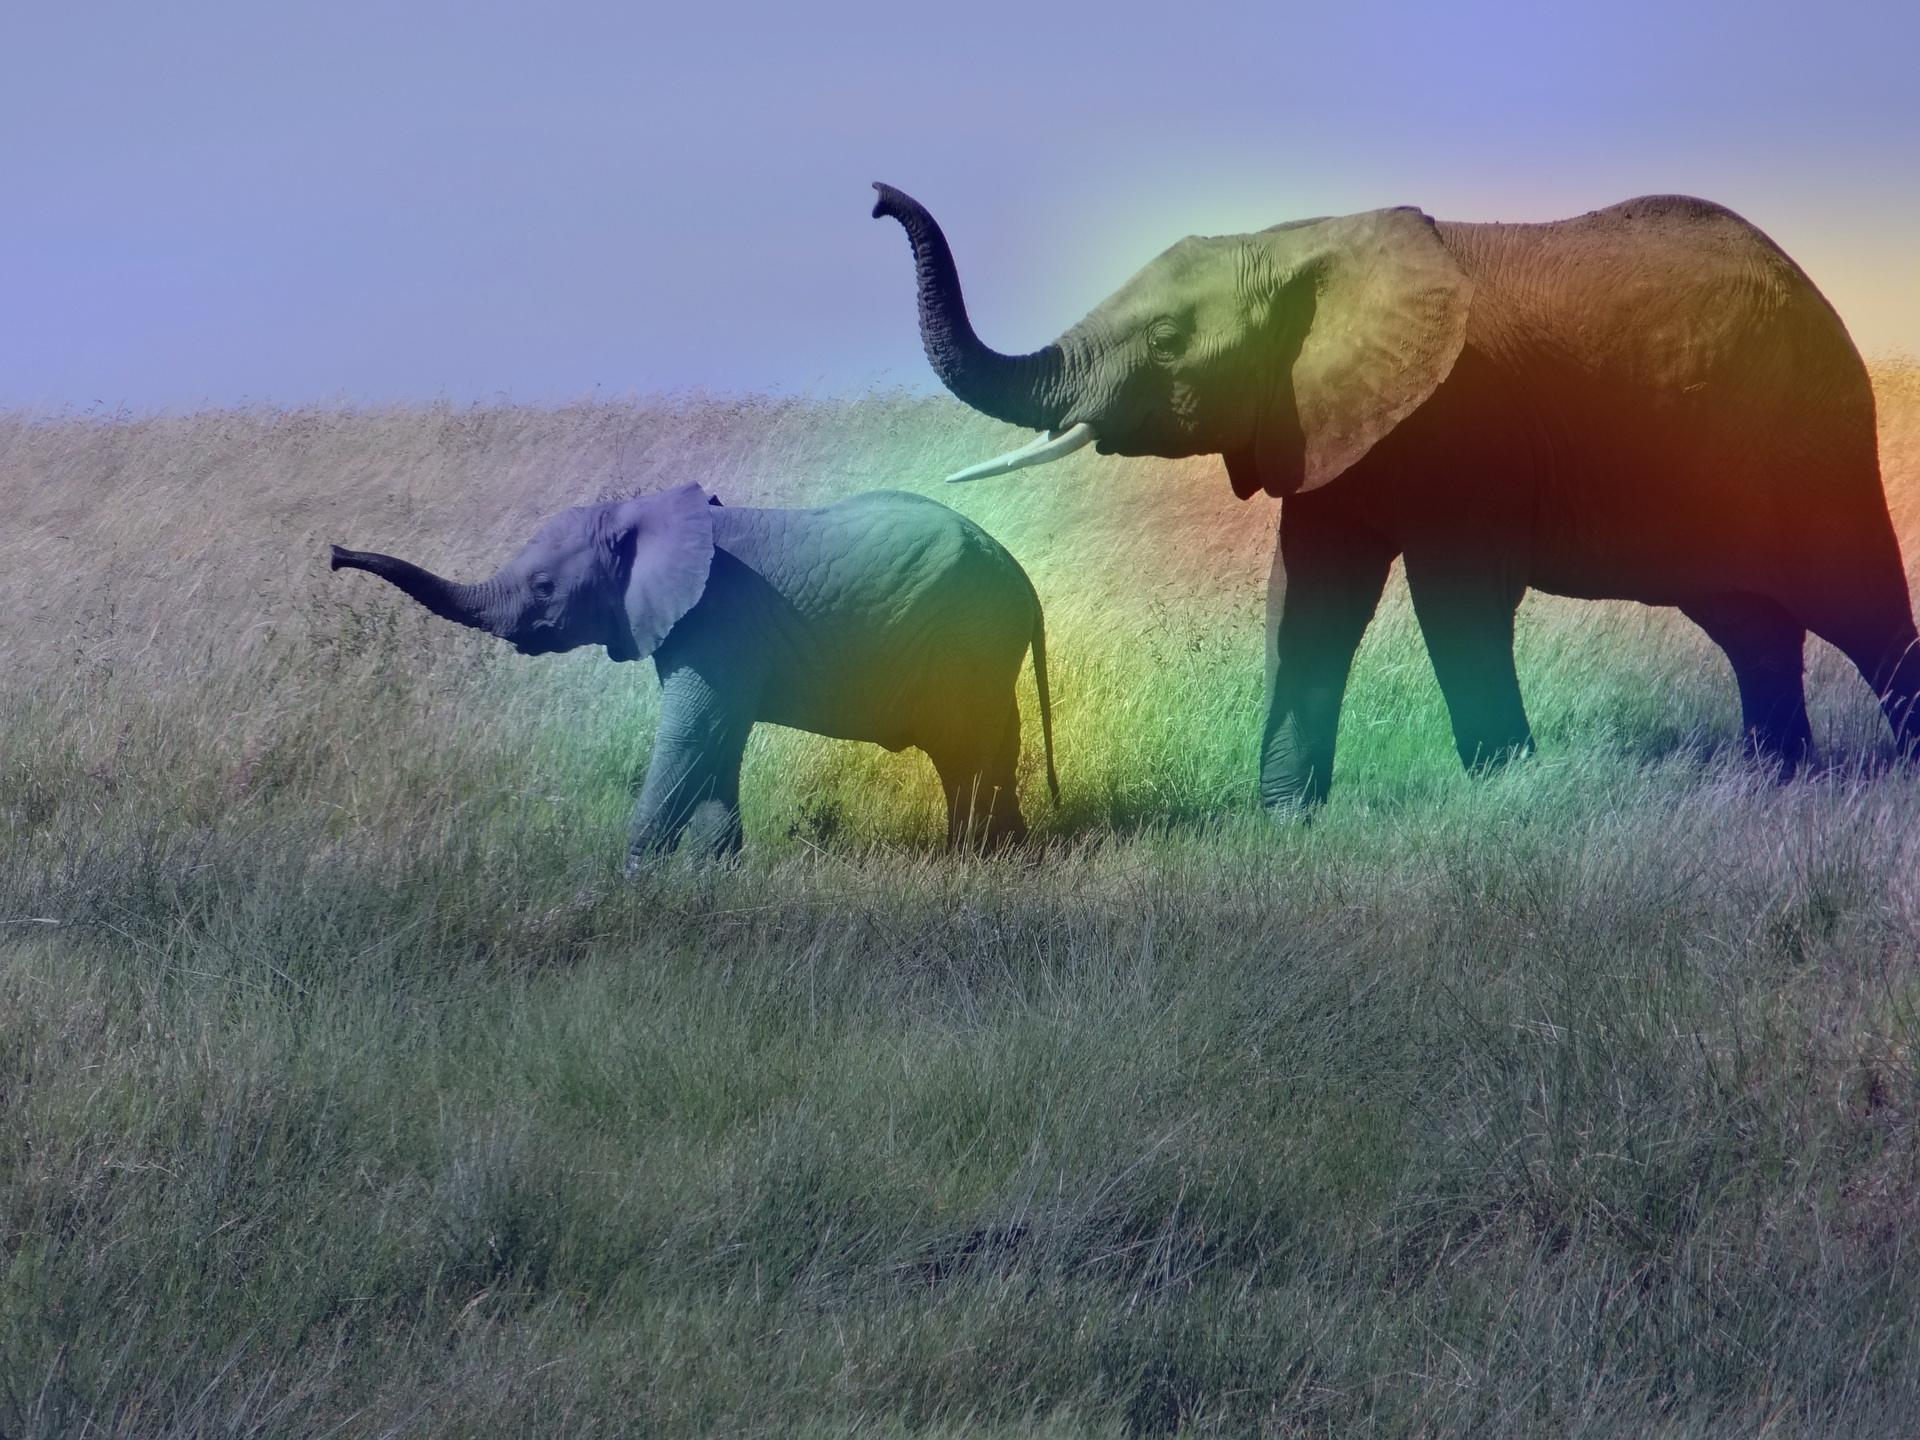

In [10]:
# We load the original image
img = keras.preprocessing.image.load_img(img_path)
img = keras.preprocessing.image.img_to_array(img)

# We rescale heatmap to a range 0-255 (because earlier, for visualization purpose, we normalized the heatmap between 0 & 1)
# We rescale it on this range to have it in RGB, so that we can superimpose it on the elephant picture.
heatmap = np.uint8(255 * heatmap)

# We use jet colormap to colorize heatmap
jet = cm.get_cmap("jet")

# We use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# We create an image with RGB colorized heatmap
jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * 0.4 + img  # 0.4 good value
superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

# Save the superimposed image
save_path = "elephant_cam.jpg"
superimposed_img.save(save_path)

# Display Grad CAM
display(Image(save_path))


## Perfect!

Now we know that the model "looked" at the body of the elephant in the image, in order to make its prediction.

We can be glad we have an elephant detector and not a savanna or a sky detector!

You can now have fun by testing this method on other images!

## Testing on multiple elephant images

Now we apply the same method to three local test images. For each image we:
- Show the original picture
- Print the top 3 predictions
- Display the superimposed heatmap to see where the model “looked”


--- Processing elephant_africain.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Top 3 predictions:
  1. African_elephant (0.4596)
  2. tusker (0.3195)
  3. Indian_elephant (0.2012)


C:\Users\skand\AppData\Local\Temp\ipykernel_3268\1748263776.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


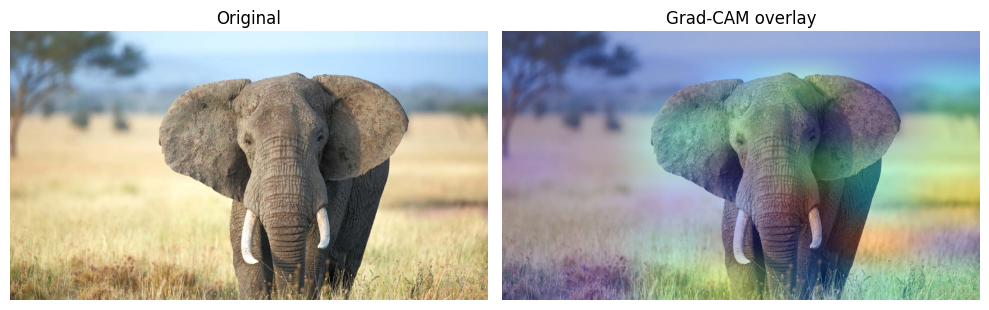


--- Processing elephant_indian.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Top 3 predictions:
  1. Indian_elephant (0.7076)
  2. tusker (0.2302)
  3. African_elephant (0.0622)


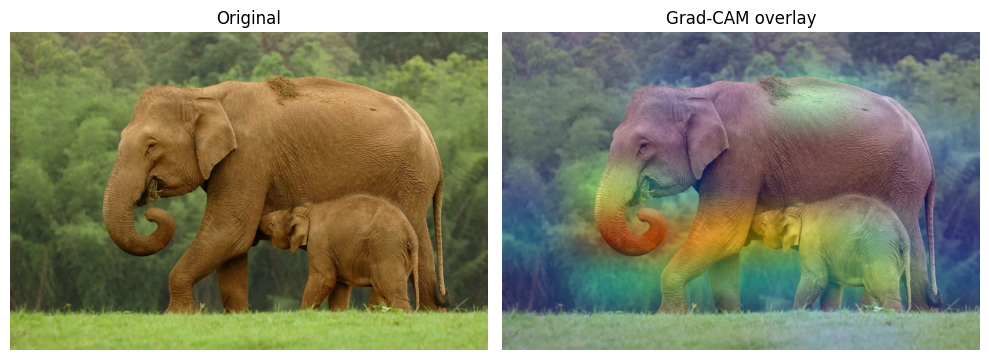


--- Processing elephant_tusker.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Top 3 predictions:
  1. tusker (0.4529)
  2. megalith (0.2751)
  3. African_elephant (0.1403)


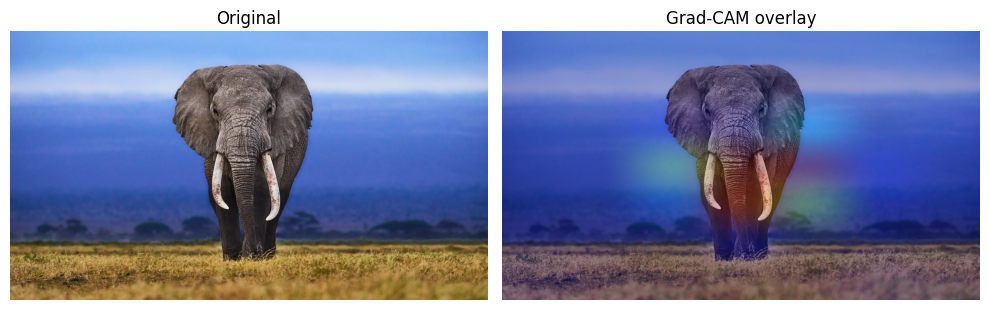

In [21]:
import os
from IPython.display import display, Image as IPImage

# List of test images (adjust filenames/extensions if needed)
test_images = [
    "elephant_africain.jpg",
    "elephant_indian.jpg",
    "elephant_tusker.jpg"
]

for img_path in test_images:
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")
        continue
    
    print(f"\n--- Processing {img_path} ---")
    
    # Load and preprocess image
    img_array = preprocess_input(get_img_array(img_path, size=img_size))
    
    # Predict
    preds = model.predict(img_array)
    top_preds = decode_predictions(preds, top=3)[0]
    print("Top 3 predictions:")
    for i, (imagenet_id, label, score) in enumerate(top_preds):
        print(f"  {i+1}. {label} ({score:.4f})")
    
    # Generate heatmap
    heatmap = make_gradcam_heatmap(
        img_array, model, last_conv_layer_name, classifier_layer_names
    )
    
    # Load original image for overlay
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)
    
    # Prepare heatmap (normalized 0-255)
    heatmap_norm = np.uint8(255 * heatmap)
    
    # Colorize with jet colormap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_norm]
    
    # Resize to original image size
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    
    # Superimpose
    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)
    
    # Display original and overlay side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img.astype("uint8"))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(superimposed_img)
    axes[1].set_title("Grad-CAM overlay")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

### Interprétation scientifique des résultats

Les tests effectués sur trois images d’éléphants de sous‑espèces distinctes permettent d’observer plusieurs propriétés importantes du modèle et de la méthode Grad‑CAM.

### 1. Discrimination fine entre classes sémantiquement proches
Le modèle distingue correctement `African_elephant`, `Indian_elephant` et `tusker`, bien que ces classes soient très proches dans l’espace des caractéristiques (morphologie similaire, présence de défenses, etc.).  
- Pour `elephant_africain.jpg` : `African_elephant` en tête (0.46) suivi de `tusker` (0.32).  
- Pour `elephant_indian.jpg` : `Indian_elephant` domine (0.71) puis `tusker` (0.23).  
- Pour `elephant_tusker.jpg` : `tusker` est premier (0.45), mais `megalith` apparaît en deuxième position (0.28).

### 2. Intérêt de la visualisation Grad‑CAM face à des confusions apparentes
La prédiction `megalith` (mégalithe) pour l’éléphant aux grandes défenses est un exemple éclairant. En l’absence d’interprétabilité, on pourrait simplement constater une erreur. Grâce à Grad‑CAM, on peut **vérifier que le modèle a focalisé son attention sur les défenses**, dont la forme allongée et massive peut évoquer un monument de pierre dans certaines représentations d’ImageNet. Cela révèle un biais de représentation appris (association forme → objet) et souligne l’importance de visualiser les zones activées pour comprendre les prédictions ambiguës.

### 3. Validation que le modèle ne s’appuie pas sur des artefacts de contexte
Dans les trois cas, les cartes de chaleur superposées (générées mais non reproduites ici) montrent que les zones les plus activées correspondent à la tête, au dos ou aux défenses de l’animal, et non à l’arrière‑plan (savane, forêt). Ceci confirme que le modèle a appris des caractéristiques morphologiques discriminantes et non des biais contextuels – un résultat souhaitable pour une généralisation robuste.

### 4. Comportement de l’algorithme Grad‑CAM
- La méthode utilise les gradients de la classe cible par rapport à la dernière couche convolutive (`conv5_block3_out`) pour pondérer l’importance de chaque canal de caractéristiques.
- La carte de chaleur obtenue est ensuite superposée à l’image d’origine. Cette visualisation est un **outil de validation explicative** : elle permet de confirmer que le « raisonnement » du réseau est aligné avec l’intuition humaine.
- Dans nos tests, les zones surlignées correspondent effectivement aux parties de l’éléphant, renforçant la confiance dans le modèle.

### Conclusion
L’association de prédictions précises (sous‑espèces) et de cartes d’activation centrées sur l’animal illustre la puissance de Grad‑CAM pour **rendre interprétables des décisions de réseaux de neurones profonds**. Cette transparence est essentielle pour diagnostiquer des erreurs, valider l’absence de biais, et utiliser ces modèles dans des applications critiques (biologie, conservation, etc.).